# Week 6 Day 5 Lab
For the final lab, we'll cover Markov Chain Monte Carlo (MCMC). Recall that Monte Carlo is simply a method of estimating through lots and lots of random sampling. Similarly, MCMC depends on lots of random sampling. However, the *way* we sample is different.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Dependent State Random Sampling
Instead of randomly sampling each point **independently**, we make the next sample **depend** on what we just sampled previously. Much like your next move in chess might be random, your next move is very dependent on where the pieces are placed currently.

In [2]:
target = [0.01, 0.01, 0.01, 0.07, 0.9]

In [3]:
def mcmc(steps, target):
    distance = []
    n = len(target)                                   # number of options
    current = np.random.choice([i for i in range(n)])       # random current starting option
    
    samples = [current]
    for i in range(steps):
        proposal = np.random.choice([i for i in range(n)])      # choose a proposed next step
        a = min(1, target[proposal] / target[current])   # how good is the proposed step compared to current step?
        
        # if a is better than a uniform at random choice, move to the proposed step!
        if np.random.uniform(0,1) < a:              
            current = proposal                          
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                           # keep track of error
        
        # if a is worse than a uniform at random choice, stay where you are!
        else:
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                     # keep track of error
        samples.append(current)                                           # keep track of movement
    return np.array(samples), distance

In [4]:
samples, distance = mcmc(10000, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.01, 0.01, 0.01, 0.07, 0.9]
MCMC estimate of the distribution:   [0.01239876 0.0119988  0.00959904 0.07269273 0.89331067]


Text(0, 0.5, 'Error')

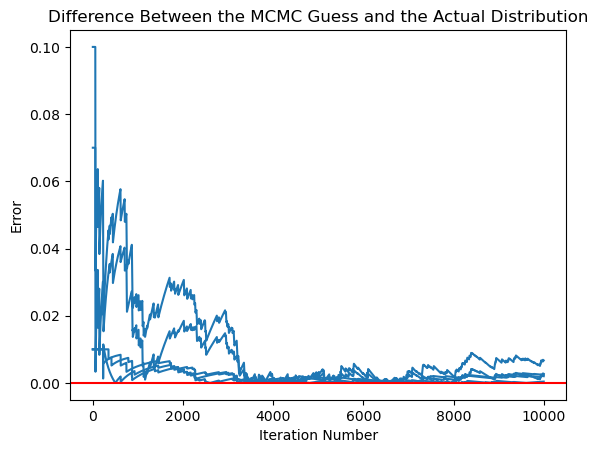

In [5]:
plt.plot([i for i in range(len(distance))], distance, c='C0')
plt.axhline(0, c='r')
plt.title('Difference Between the MCMC Guess and the Actual Distribution')
plt.xlabel('Iteration Number')
plt.ylabel('Error')

In [ ]:
# computing region in circle

def region(x, y):
    if x**2+y**2<=1:     # in circle
        return 0
    if x>=0 and y>=0: # top left
        return 1
    elif x<0 and y>= 0: #top right
        return 2
    elif x<0 and y<0: #bottom left
        return 3
    else:                 # bottom right
        return 4


In [7]:
# mcmc sampling code

def mcmccircle(nsteps, target, step_size=0.2):
    x, y = 0.0, 0.0  # start at center
    samples = []

    for i in range(nsteps):
        xprop = x +np.random.normal(0, step_size) # propose a movement in x
        yprop = y +np.random.normal(0, step_size) # propose a movement in y
        if not (-1 <= xprop <= 1 and -1 <= yprop <= 1): # if outside, reject
            samples.append((x, y))
            continue
        rcurrent = region(x, y) # which region are you
        rprop = region(xprop, yprop) # which region is the propsed move
        alpha = min(1, target[rprop] / target[rcurrent]) # decide whether to move there

        if np.random.rand() < alpha:
            x, y = xprop, yprop

        samples.append((x, y))

    return np.array(samples)

In [8]:
# plotting code

def plotmcmc(samples):
    x = samples[:,0]
    y = samples[:,1]
    colors = []
    for i, j in zip(x, y):
        colors.append(region(i, j))
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c=colors, s=5)
    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))

    plt.title("MCMC on the Circle")
    plt.xlim([-1,1])
    plt.ylim([-1,1])
    plt.show()

In [9]:
target = [.9,.01,.01,.07,.01]
print(target)

[0.9, 0.01, 0.01, 0.07, 0.01]


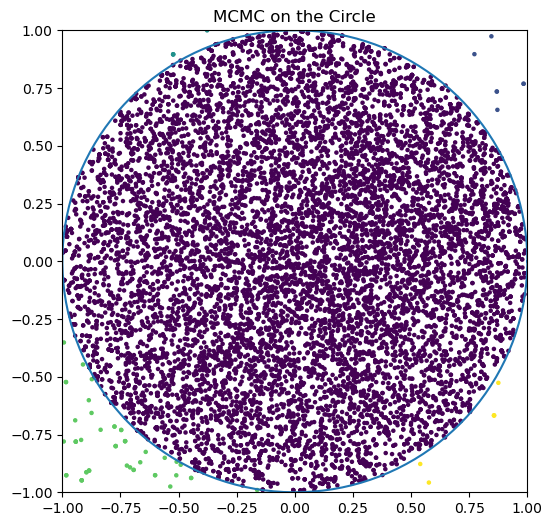

In [10]:
plotmcmc(mcmccircle(10000, target))

### Problem 1
Try running `mcmc` for 100, 1,000, and 10,000 steps to compare the estimates. What do you notices?

In [14]:
samples, distance = mcmc(100, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.9, 0.01, 0.01, 0.07, 0.01]
MCMC estimate of the distribution:   [0.97029703 0.         0.         0.02970297 0.        ]


In [15]:
samples, distance = mcmc(1000, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.9, 0.01, 0.01, 0.07, 0.01]
MCMC estimate of the distribution:   [0.9040959  0.01298701 0.00699301 0.06393606 0.01198801]


In [16]:
samples, distance = mcmc(10000, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.9, 0.01, 0.01, 0.07, 0.01]
MCMC estimate of the distribution:   [0.89831017 0.01079892 0.01159884 0.06809319 0.01119888]


In [ ]:
#Get's closer and closer to the target distribution

In [39]:
sample = mcmccircle(1000, target)
sample[0]

array([-0.03138744,  0.00102561])

### Problem 2
Write code that will run `mcmccircle()` until you have 1,000 points in the bottom right corner.

In [ ]:
def hit1000(x):
    sample = mcmccircle(x, target)
    end = 0
    while (end <= 1000):
         for i in sample:
             if (region(i[0], i[1]) == 4):
                 end+= 1 
             else:
                 np.append(sample, mcmccircle(1000, target))
    return sample

In [ ]:
plotmcmc(hit1000(1000))

### Problem 3
Create your own `target` to be equal on all regions in `mcmc()`. Generate 100, 1,000, and 10,000 samples. Compare the averages of these runs. Do they converge?

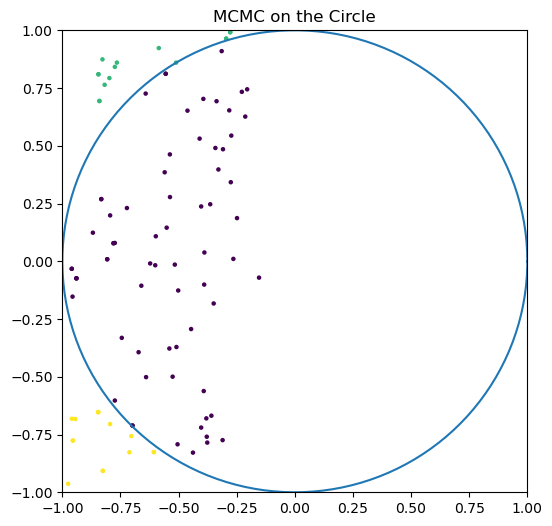

In [22]:
target = [0.2, 0.2, 0.2, 0.2, 0.2]
plotmcmc(mcmccircle(100, target))


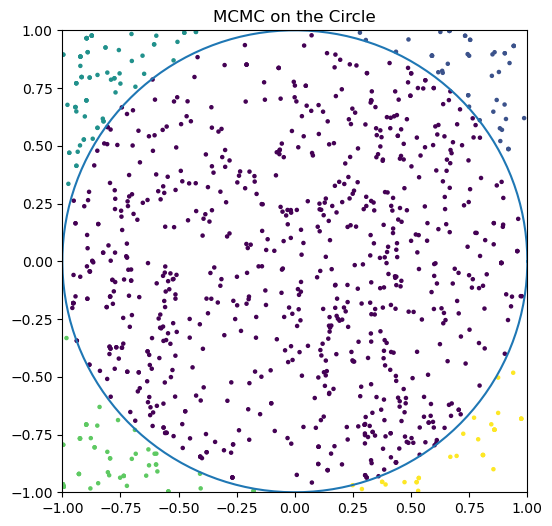

In [23]:
target = [0.2, 0.2, 0.2, 0.2, 0.2]
plotmcmc(mcmccircle(1000, target))


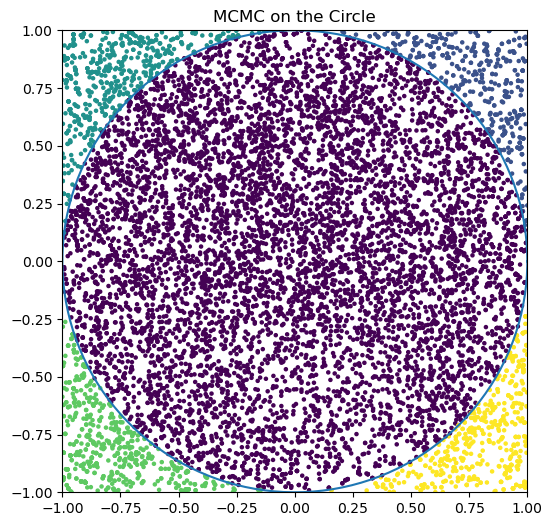

In [24]:
target = [0.2, 0.2, 0.2, 0.2, 0.2]
plotmcmc(mcmccircle(10000, target))


In [ ]:
#They do not converge into one spot, distribution is even along the square